# LIBRERIAS


In [1]:
import os
import cudf
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
import optuna
from optuna.samplers import GPSampler
from optuna.trial import TrialState
from optuna.visualization import plot_param_importances, plot_contour,  plot_slice, plot_optimization_history




print('cuDF:', cudf.__version__)
print('GPU:', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())


cuDF: 26.08.01
GPU: NVIDIA GeForce RTX 3090


# URLS

In [2]:
BASE_URL = os.path.join(
    os.path.expanduser("~"),
    "code", "DMEyF", "dmeyf2026"
)

DATA_URL = os.path.join(BASE_URL, "DATA")
DATASETS_URL = os.path.join(DATA_URL, "DATASETS")
EXP_URL = os.path.join(DATA_URL, "EXP")
dataset_url = os.path.join(DATASETS_URL,'competencia_01_crudo.csv')

experiment_name = "exp308"
EXPERIMENT_URL = os.path.join(EXP_URL, experiment_name)

os.makedirs(EXPERIMENT_URL, exist_ok=True)

# CONSTANTES Y DEMAS

In [3]:
SEED = 230047

# LEEMOS DATASET

In [4]:
# cudf no pandas -> GPU
df = cudf.read_csv(
    dataset_url,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

In [5]:
df.head()

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_madelantodolares,Visa_fultimo_cierre,Visa_mpagado,Visa_mpagospesos,Visa_mpagosdolares,Visa_fechaalta,Visa_mconsumototal,Visa_cconsumos,Visa_cadelantosefectivo,Visa_mpagominimo
0,12159854,202103,1,0,0,56,134,688.41,26701.84,98.82,...,0.0,1,0.0,-16247.77,0.0,4056,15732.34,1,0,1137.81
1,12159858,202103,1,0,0,48,102,78.43,24418.75,-73.62,...,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,NaN
2,12160484,202103,1,0,0,60,55,8101.55,3162.23,13399.50,...,0.0,1,0.0,-31103.23,0.0,1632,2860.54,2,0,19858.89
3,12160591,202103,1,0,0,46,275,14825.78,138050.05,1146.27,...,0.0,1,0.0,-13733.44,0.0,2122,1419.36,3,0,1231.65
4,12160747,202103,1,0,0,47,194,2015.61,31240.49,1791.25,...,0.0,1,0.0,0.0,0.0,5901,1286.93,1,0,82.11


# GENERACION CLASE TERNARIA

In [6]:
# Índice de mes continuo para cada fila.
year = df['foto_mes'] // 100
month = df['foto_mes'] % 100
df['mes_idx'] = year * 12 + month

# Tabla de existencia: una fila por cliente y mes.
presencia = (
    df[['numero_de_cliente', 'mes_idx']]
    .drop_duplicates()
    .assign(presente=cp.int8(1))
)

# Presencia en t+1: desplazamos la clave para que coincida con el mes actual t.
presencia_t1 = presencia.rename(columns={'mes_idx': 'mes_idx_t1', 'presente': 'presente_t1'})
presencia_t1['mes_idx'] = presencia_t1['mes_idx_t1'] - 1
presencia_t1 = presencia_t1[['numero_de_cliente', 'mes_idx', 'presente_t1']]

# Presencia en t+2.
presencia_t2 = presencia.rename(columns={'mes_idx': 'mes_idx_t2', 'presente': 'presente_t2'})
presencia_t2['mes_idx'] = presencia_t2['mes_idx_t2'] - 2
presencia_t2 = presencia_t2[['numero_de_cliente', 'mes_idx', 'presente_t2']]

df = df.merge(presencia_t1, on=['numero_de_cliente', 'mes_idx'], how='left')
df = df.merge(presencia_t2, on=['numero_de_cliente', 'mes_idx'], how='left')

tiene_t1 = df['presente_t1'].fillna(0).astype('bool')
tiene_t2 = df['presente_t2'].fillna(0).astype('bool')

# Último mes observado del dataset: no tiene horizonte futuro verificable.
ultimo_mes_idx = int(df['mes_idx'].max())

df['ternaria'] = cudf.Series(None, index=df.index, dtype='str')
df.loc[df['mes_idx'] < ultimo_mes_idx - 1, 'ternaria'] = 'baja+1'
df.loc[(df['mes_idx'] < ultimo_mes_idx - 1) & tiene_t1, 'ternaria'] = 'baja+2'
df.loc[(df['mes_idx'] < ultimo_mes_idx - 1) & tiene_t1 & tiene_t2, 'ternaria'] = 'continua'

# Penúltimo mes: sólo puede determinarse baja+1; si continúa queda sin clase.
df.loc[(df['mes_idx'] == ultimo_mes_idx - 1) & ~tiene_t1, 'ternaria'] = 'baja+1'

# Quitamos columnas auxiliares.
df = df.drop(columns=['mes_idx', 'presente_t1', 'presente_t2'])
# Nulos en vez de NAN en CUDF
df.loc[df["ternaria"] == "", "ternaria"] = None

In [7]:
cudf.crosstab(df['ternaria'].fillna('NA'), df['foto_mes'])

foto_mes,202103,202104,202105,202106,202107,202108
ternaria,,,,,,
NA,0,0,0,0,163245,164647
baja+1,1019,964,1143,874,1103,0
baja+2,960,1139,870,1098,0,0
continua,160921,161181,161755,162142,0,0


In [8]:
df_completo = df.copy()

# Acción :  Jugar con  minsplit, minbucket y maxdepth

## Hiperparametros

In [9]:
semilla= SEED
minsplit = 5000
minbucket = 2000
maxdepth = 10

## Particion Dataset

In [10]:

# a partir de ahora solo trabajo con 202106, el ultimo mes que tiene clase
df = df.loc[df['foto_mes'] == 202106] # defino donde voy a entrenar

train_idx, test_idx = train_test_split(
    df.index.to_numpy(),
    test_size=0.5,
    stratify=df["ternaria"].to_numpy(),
    random_state=semilla
)

In [11]:
len(train_idx), len(test_idx)

(82057, 82057)

In [12]:
train_df_cpu = df.loc[train_idx].to_pandas() #con to_pandas lo mandamos a ram para cpu
test_df_cpu = df.loc[test_idx].to_pandas() 

## Entreno el modelo


### CPU VERSION

In [13]:
X_train_cpu = train_df_cpu.drop( columns = ['ternaria'])
y_train_cpu = train_df_cpu['ternaria']

X_test_cpu = test_df_cpu.drop( columns =['ternaria'])
y_test_cpu = test_df_cpu['ternaria']

In [14]:
modelo = DecisionTreeClassifier(
    ccp_alpha=0.0,                 # equivalente conceptual a cp<0 ?
    min_samples_split=minsplit,
    min_samples_leaf=minbucket,
    max_depth=maxdepth,
    random_state=semilla
)

In [15]:
modelo.fit(X_train_cpu, y_train_cpu)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5000
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2000
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",230047
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number of

In [16]:
# Buscamos posicion de baja+2 0,1 o 2?
for i, clase in enumerate(modelo.classes_):
    print(clase, '->', i)

pos_baja2 = 1

baja+1 -> 0
baja+2 -> 1
continua -> 2


In [17]:
pred_train_cpu = modelo.predict_proba(X_train_cpu)
pred_test_cpu = modelo.predict_proba(X_test_cpu)

In [18]:
# Creamos df con la clase ternaria real -> nuestro "y" previo
tb_prediccion_train = y_train_cpu.to_frame(name="ternaria")
# Agregamos columna con la probabilidad predicha de baja+2
tb_prediccion_train["prob_baja2"] = pred_train_cpu[:, pos_baja2]

tb_prediccion_test = y_test_cpu.to_frame(name="ternaria")
tb_prediccion_test["prob_baja2"] = pred_test_cpu[:, pos_baja2]

In [19]:
#------------------ TRAIN ----------------------
# ordenamos descendiente por probabilidad de baja2 segun prediccion
tb_prediccion_train = tb_prediccion_train.sort_values(
    by="prob_baja2",
    ascending=False
).copy()

# -> tomado de la notebook en R tb_prediccion[, gan := 2 *ifelse(clase_ternaria == "BAJA+2", 1072500, -27500)]
tb_prediccion_train["gan"] = 2 * np.where(
    tb_prediccion_train["ternaria"] == "baja+2",
    1072500,
    -27500
)
# Acumulamos
tb_prediccion_train["ganancia_acumulada"] = (
    tb_prediccion_train["gan"].cumsum()
)

# posicion
tb_prediccion_train["pos"] = np.arange(
    1, len(tb_prediccion_train) + 1
)


#------------------ TEST ----------------------
tb_prediccion_test = tb_prediccion_test.sort_values(
    by="prob_baja2",
    ascending=False
).copy()

tb_prediccion_test["gan"] = 2 * np.where(
    tb_prediccion_test["ternaria"] == "baja+2",
    1072500,
    -27500
)

tb_prediccion_test["ganancia_acumulada"] = (
    tb_prediccion_test["gan"].cumsum()
)

tb_prediccion_test["pos"] = np.arange(
    1, len(tb_prediccion_test) + 1
)

### Ploteamos

In [20]:
def plot_curvas_ganancia(
    tb_train,
    tb_test,
    amostrar=20_000
):
    train_plot = tb_train.loc[tb_train["pos"] <= amostrar]
    test_plot = tb_test.loc[tb_test["pos"] <= amostrar]

    plt.figure(figsize=(10, 5))

    plt.plot(
        train_plot["pos"],
        train_plot["ganancia_acumulada"],
        label="train"
    )

    plt.plot(
        test_plot["pos"],
        test_plot["ganancia_acumulada"],
        label="test"
    )

    plt.xlabel("Posición")
    plt.ylabel("Ganancia acumulada")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

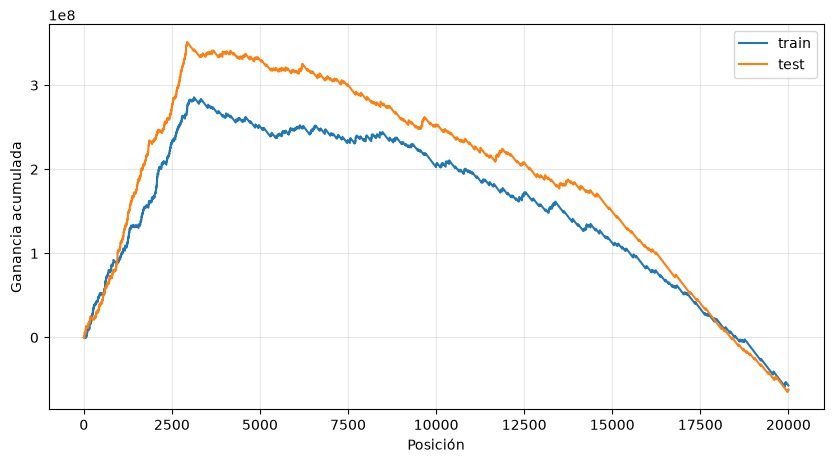

In [21]:
plot_curvas_ganancia(
    tb_prediccion_train,
    tb_prediccion_test
)

### GPU VERSION

In [22]:
#TODO

# BAYESIAN OPTIMIZATION
    OPTUNA GPSAMPLER

In [23]:
print(optuna.__version__)

4.9.0


## Parametros y optimizer

In [24]:
semilla= SEED
n_startup_trials = 16
bo_iter = 200
n_trials_total = n_startup_trials + bo_iter  # 56


In [25]:
df_bo_cpu = (
    df_completo
    .loc[df_completo["foto_mes"] == 202104]
    .to_pandas()
)

X_bo_cpu = df_bo_cpu.drop(columns=["ternaria"])
y_bo_cpu = df_bo_cpu["ternaria"]

particionador = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=semilla
)

folds = list(
    particionador.split(X_bo_cpu, y_bo_cpu)
)

In [26]:
# Algo equivalente a ArbolSimple en R

def evaluar_fold(
    X,
    y,
    train_idx,
    test_idx,
    parametros,
    semilla
):
    # Separo las filas correspondientes al entrenamiento
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    # Separo las filas correspondientes al testing
    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    # Creo el árbol con los hiperparámetros del trial actual
    class_weight = {
    "continua": 1.0,
    "baja+1": 1.0,
    "baja+2": parametros["baja2_weight"]
    }
    modelo = DecisionTreeClassifier(
        ccp_alpha=parametros["ccp_alpha"],
        min_samples_split=parametros["minsplit"],
        min_samples_leaf=parametros["minbucket"],
        max_depth=parametros["maxdepth"],
        random_state=semilla,
        class_weight=class_weight
    )

    # Entreno el árbol usando cuatro de los cinco folds
    modelo.fit(X_train, y_train)

    # Obtengo las probabilidades de las tres clases
    # para las filas del fold de testing
    prediccion = modelo.predict_proba(X_test)

    # Busco qué columna corresponde a baja+2
    pos_baja2 = list(modelo.classes_).index("baja+2")

    # Extraigo solamente la probabilidad predicha de baja+2
    prob_baja2 = prediccion[:, pos_baja2]

    # Recupero el peso usado para baja+2
    peso_baja2 = parametros["baja2_weight"]

    # Quito el efecto del peso de clase
    prob_baja2_desponderada = (
        (prob_baja2 / peso_baja2)
        / (
            (prob_baja2 / peso_baja2)
            + (1 - prob_baja2)
        )
    )

    # Selecciono las filas cuya probabilidad supera el umbral
    # seleccionados = prob_baja2 > (1 / 40)
    seleccionados = prob_baja2_desponderada > (1 / 40)

    # Recupero las clases reales del fold de testing
    clases_reales = y_test.to_numpy()

    # Calculo la ganancia usando la clase real
    # únicamente para las filas que superaron el umbral
    ganancia_fold = np.where(
        clases_reales[seleccionados] == "baja+2",
        1072500,
        -27500
    ).sum()

    # Devuelvo la ganancia no normalizada de este fold
    return int(ganancia_fold)

In [27]:
#detalle de la estructura de folds.
type(folds), type(folds[0]), len(folds[0]), type(folds[0][0]),  folds[0][0].shape, folds[0][1].shape

(list, tuple, 2, numpy.ndarray, (130627,), (32657,))

In [28]:
# Analogo a "ArbolesCrossValidation"
def evaluar_cross_validation(
    X,
    y,
    folds,   
    parametros,
    semilla
):
    # Guardo aquí la ganancia obtenida en cada fold
    ganancias = []

    # Cada elemento de folds contiene:
    # - índices para entrenamiento
    # - índices para testing
    for train_idx, test_idx in folds:

        # Entreno y evalúo el árbol para este fold
        ganancia_fold = evaluar_fold(
            X=X,
            y=y,
            train_idx=train_idx,
            test_idx=test_idx,
            parametros=parametros,
            semilla=semilla
        )

        # Guardo el resultado del fold
        ganancias.append(ganancia_fold)

    # Calculo la ganancia promedio de los cinco folds
    ganancia_promedio = np.mean(ganancias)

    # Normalizo al tamaño aproximado del dataset completo.
    # Con cinco folds, esto es equivalente a sumar las ganancias.
    ganancia_normalizada = ganancia_promedio * len(folds)

    # Devuelvo una única ganancia para esta combinación
    # de hiperparámetros
    return float(ganancia_normalizada)

In [29]:
# Funcion con parametros para OPTUNA

def objective(trial):
    # ccp_alpha = trial.suggest_float("ccp_alpha", 0, 0.1)
    minsplit = trial.suggest_int("minsplit", 2, 8000)
    maxdepth = trial.suggest_int("maxdepth", 2, 20)
    baja2_weight = trial.suggest_float("weight_2", 1, 300)

    # minbuket NO PUEDE ser mayor que la mitad de minsplit
    # Creamos un espacio siempre valido de valores en minbucket para imitar el comportamiento en R y que no se descuenten iteraciones q fueron podadas
    # sugerencia entre 0 y 1
    minbucket_ratio = trial.suggest_float("minbucket_ratio",0.0,1.0)
    # Definimos el "techo" de minbucket
    max_minbucket = min(20000, minsplit // 2)
    # escalamos la sugerencia de 0-1 a 1-max_minbucket 
    minbucket = 1 + int(minbucket_ratio * (max_minbucket - 1))

    # Guardo el minbucket efectivo porque no es un parámetro
    # sugerido directamente por Optuna
    trial.set_user_attr(
        "minbucket",
        minbucket
    )

    # Agrupo los parámetros con los nombres esperados
    # por evaluar_fold()
    parametros = {
        # "ccp_alpha": ccp_alpha,
        "ccp_alpha": 0,
        "minsplit": minsplit,
        "minbucket": minbucket,
        "maxdepth": maxdepth,
        "baja2_weight":baja2_weight
    }

    # Evalúo esta combinación usando siempre 
    # los mismos cinco folds <<<<->>>>> cuidado que aca hay variables q no estan en el arbol de llamadas y son globales!!!!!! 
    ganancia = evaluar_cross_validation(
        X=X_bo_cpu,
        y=y_bo_cpu,
        folds=folds,
        parametros=parametros,
        semilla=semilla
    )

    # Este es el valor que GPSampler intentará maximizar
    return ganancia

In [30]:
sampler = GPSampler(
    seed=semilla,
    n_startup_trials=n_startup_trials,
    deterministic_objective=False
)

/tmp/ipykernel_323248/3798218501.py:1: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler = GPSampler(


In [31]:
# Nombre del archivo donde Optuna guardará los trials
file_name = "optuna_study.db"

# Ruta completa dentro de la carpeta del experimento
study_db_url = os.path.join(
    EXPERIMENT_URL,
    file_name
)

# Optuna utiliza el formato de conexión de SQLAlchemy
storage_url = f"sqlite:///{study_db_url}"

# Creo el estudio de optimización
study = optuna.create_study(
    # Nombre lógico del estudio dentro de la base SQLite
    study_name=experiment_name,

    # La ganancia debe ser maximizada
    direction="maximize",

    # GPSampler configurado anteriormente
    sampler=sampler,

    # Base donde se guardarán parámetros, ganancias y estados
    storage=storage_url,

    # Si el estudio ya existe, lo recupera en lugar de fallar
    load_if_exists=True
)

[I 2026-09-02 21:22:08,855] Using an existing study with name 'exp308' instead of creating a new one.


In [32]:
# Cuento los trials que ya finalizaron correctamente
trials_completos = sum(
    trial.state == TrialState.COMPLETE
    for trial in study.trials
)

# Calculo cuántos faltan para llegar al total definido
trials_restantes = max(
    0,
    n_trials_total - trials_completos
)

print("Trials completos:", trials_completos)
print("Trials restantes:", trials_restantes)

# Ejecuto solamente los trials que todavía faltan
if trials_restantes > 0:
    study.optimize(
        objective,
        show_progress_bar=True,
        n_trials=trials_restantes
    )
else:
    print("c'est fini")

Trials completos: 216
Trials restantes: 0
c'est fini


In [33]:
optuna.visualization.plot_optimization_history(study)

In [34]:
plot_slice(study)

In [35]:
plot_contour(study)

In [36]:
plot_contour(study, params=["maxdepth", "minsplit"])

In [37]:
study.best_trial

FrozenTrial(number=208, state=<TrialState.COMPLETE: 1>, values=[453805000.0], datetime_start=datetime.datetime(2026, 9, 2, 17, 40, 51, 56072), datetime_complete=datetime.datetime(2026, 9, 2, 17, 41, 6, 119354), params={'minsplit': 4680, 'maxdepth': 7, 'weight_2': 300.0, 'minbucket_ratio': 0.21344525373965872}, user_attrs={'minbucket': 500}, system_attrs={'gp:relative_params:0': '{"maxdepth": 7, "minbucket_ratio": 0.21344525373965872, "minsplit": 4680, "weight_2": 300.0}'}, intermediate_values={}, distributions={'minsplit': IntDistribution(high=8000, log=False, low=2, step=1), 'maxdepth': IntDistribution(high=20, log=False, low=2, step=1), 'weight_2': FloatDistribution(high=300.0, log=False, low=1.0, step=None), 'minbucket_ratio': FloatDistribution(high=1.0, log=False, low=0.0, step=None)}, trial_id=209, value=None)

# Poniendonos serios con los resultados previos

## Levantamos resultados de todos los experimetnos hechos

In [38]:
# Experimetnos hechos 
exp_folders = os.listdir(EXP_URL)
exp_db_urls = []
for folder in exp_folders:
    exp_folder = os.path.join(EXP_URL,folder)
    exp_file = os.listdir(exp_folder)[0]
    exp_file_url = os.path.join(exp_folder, exp_file)
    exp_db_urls.append(exp_file_url)


In [39]:
resultados_experimentos = []

for db_url in exp_db_urls:

    #ruta en formato URL de SQLite
    storage_url = f"sqlite:///{os.path.abspath(db_url)}"

    # estudios almacenados cada DB
    estudios = optuna.study.get_all_study_summaries(
        storage=storage_url
    )

    for detalle_estudios in estudios:

        # Cargo el estudio
        study = optuna.load_study(
            study_name=detalle_estudios.study_name,
            storage=storage_url
        )

        # Convierto todos sus trials en una tabla
        trials_df = study.trials_dataframe()

        resultados_experimentos.append({
            "experimento": os.path.basename(os.path.dirname(db_url)),
            "study_name": study.study_name,
            "db_url": db_url,
            "study": study,
            "trials": trials_df
        })

In [40]:
# pasamos resultados a df

tablas = []

for resultado in resultados_experimentos:
    tabla = resultado["trials"].copy()
    tabla["experimento"] = resultado["experimento"]
    tabla["study_name"] = resultado["study_name"]
    tablas.append(tabla)

# Tabla conjunta en pandas
resultados_df_cpu = pd.concat(
    tablas,
    ignore_index=True,
    sort=False
)

# Conversión a cuDF para trabajar en GPU
resultados_df = cudf.from_pandas(resultados_df_cpu)

resultados_df.tail()

,number,value,datetime_start,datetime_complete,duration,params_ccp_alpha,params_maxdepth,params_minbucket_ratio,params_minsplit,user_attrs_minbucket,system_attrs_gp:relative_params:0,state,experimento,study_name,params_weight_2
528,111,337122500.0,2026-09-02 15:32:44.174490,2026-09-02 15:32:59.511626,0 days 00:00:15.337136,NaN,9,0.000000,38198,1,"{""maxdepth"": 9, ""minbucket_ratio"": 0.0, ""minsp...",COMPLETE,exp307,exp307,NaN
529,112,350405000.0,2026-09-02 15:32:59.543034,2026-09-02 15:33:12.443174,0 days 00:00:12.900140,NaN,10,1.000000,13215,6606,"{""maxdepth"": 10, ""minbucket_ratio"": 0.99999999...",COMPLETE,exp307,exp307,NaN
530,113,350405000.0,2026-09-02 15:33:12.473908,2026-09-02 15:33:25.078252,0 days 00:00:12.604344,NaN,23,0.980808,14015,6872,"{""maxdepth"": 23, ""minbucket_ratio"": 0.98080849...",COMPLETE,exp307,exp307,NaN
531,114,415937500.0,2026-09-02 15:33:25.101583,2026-09-02 15:33:49.432753,0 days 00:00:24.331170,NaN,22,0.539732,2424,654,"{""maxdepth"": 22, ""minbucket_ratio"": 0.53973224...",COMPLETE,exp307,exp307,NaN
532,115,358407500.0,2026-09-02 15:33:49.458919,2026-09-02 15:34:05.338217,0 days 00:00:15.879298,NaN,23,1.000000,7082,3541,"{""maxdepth"": 23, ""minbucket_ratio"": 1.0, ""mins...",COMPLETE,exp307,exp307,NaN


## Tomamos los mejores 5 resultados para cada experimetno

In [41]:
top_5 = (
    resultados_df[resultados_df["state"] == "COMPLETE"]
    .sort_values(
        by=["experimento", "value"],
        ascending=[True, False]
    )
    .groupby("experimento")
    .head(5)
    .reset_index(drop=True)
)
top_5.sort_values(by='value', ascending=False)

,number,value,datetime_start,datetime_complete,duration,params_ccp_alpha,params_maxdepth,params_minbucket_ratio,params_minsplit,user_attrs_minbucket,system_attrs_gp:relative_params:0,state,experimento,study_name,params_weight_2
10,65,465657500.0,2026-09-02 14:33:58.794639,2026-09-02 14:34:18.604431,0 days 00:00:19.809792,NaN,10,0.321147,1311,211,"{""maxdepth"": 10, ""minbucket_ratio"": 0.32114658...",COMPLETE,exp306,exp306,NaN
11,106,464447500.0,2026-09-02 14:48:28.053542,2026-09-02 14:48:48.176581,0 days 00:00:20.123039,NaN,10,0.370409,1247,231,"{""maxdepth"": 10, ""minbucket_ratio"": 0.37040919...",COMPLETE,exp306,exp306,NaN
12,89,463430000.0,2026-09-02 14:42:23.642503,2026-09-02 14:42:43.759971,0 days 00:00:20.117468,NaN,10,0.277358,1441,200,"{""maxdepth"": 10, ""minbucket_ratio"": 0.27735793...",COMPLETE,exp306,exp306,NaN
13,90,463430000.0,2026-09-02 14:42:43.789930,2026-09-02 14:43:03.860395,0 days 00:00:20.070465,NaN,10,0.278030,1441,200,"{""maxdepth"": 10, ""minbucket_ratio"": 0.27803010...",COMPLETE,exp306,exp306,NaN
14,91,463430000.0,2026-09-02 14:43:03.891270,2026-09-02 14:43:23.994350,0 days 00:00:20.103080,NaN,10,0.279170,1440,201,"{""maxdepth"": 10, ""minbucket_ratio"": 0.27916985...",COMPLETE,exp306,exp306,NaN
20,208,453805000.0,2026-09-02 17:40:51.056072,2026-09-02 17:41:06.119354,0 days 00:00:15.063282,NaN,7,0.213445,4680,500,"{""maxdepth"": 7, ""minbucket_ratio"": 0.213445253...",COMPLETE,exp308,exp308,300.0
21,132,451247500.0,2026-09-02 17:18:12.597794,2026-09-02 17:18:28.626931,0 days 00:00:16.029137,NaN,9,0.226442,5840,661,"{""maxdepth"": 9, ""minbucket_ratio"": 0.226442198...",COMPLETE,exp308,exp308,270.0720209
22,147,451247500.0,2026-09-02 17:23:05.948763,2026-09-02 17:23:21.724304,0 days 00:00:15.775541,NaN,9,0.352367,5477,965,"{""maxdepth"": 9, ""minbucket_ratio"": 0.352366796...",COMPLETE,exp308,exp308,254.3303805
23,198,451247500.0,2026-09-02 17:37:45.460398,2026-09-02 17:38:02.543303,0 days 00:00:17.082905,NaN,20,0.289284,6692,968,"{""maxdepth"": 20, ""minbucket_ratio"": 0.28928430...",COMPLETE,exp308,exp308,283.0610013
24,109,450917500.0,2026-09-02 17:10:00.555843,2026-09-02 17:10:16.968978,0 days 00:00:16.413135,NaN,9,0.172076,5677,489,"{""maxdepth"": 9, ""minbucket_ratio"": 0.172076295...",COMPLETE,exp308,exp308,266.2093756


## Split de datos por semilla

In [ ]:
np.random.seed(SEED)
n_semillas = 5
semillas = np.random.randint(1,100, n_semillas)
test_size = 0.3

In [ ]:
# a partir de ahora solo trabajo con 202104, el ultimo mes que tiene clase
# df = df.loc[df['foto_mes'] == 202104] # defino donde voy a entrenar
df= df_completo.loc[df_completo["foto_mes"] == 202104]

def seed_indices(seed, test_size):
    train_idx, test_idx = train_test_split(
        df.index.to_numpy(),
        test_size=test_size,
        stratify=df["ternaria"].to_numpy(),
        random_state=seed
    )
    return train_idx, test_idx

In [54]:
# Datos a CPU (seria vram a ram), ese df es de cudf, no de pandas
df_mc_cpu = df.to_pandas()

X_mc_cpu = df_mc_cpu.drop(
    columns=["ternaria"],
    errors="ignore"
)

y_mc_cpu = df_mc_cpu["ternaria"]

top_5_cpu = top_5.to_pandas()

resultados_mc = []

for seed in semillas:

    print(f"Partición con semilla {seed}")

    # generamos seeds para las pruebas
    train_idx, test_idx = seed_indices(seed, test_size)

    X_train = X_mc_cpu.loc[train_idx]
    y_train = y_mc_cpu.loc[train_idx]

    X_test = X_mc_cpu.loc[test_idx]
    y_test = y_mc_cpu.loc[test_idx]

    for _, trial in top_5_cpu.iterrows():

        minsplit = int(trial["params_minsplit"])
        minbucket = int(trial["user_attrs_minbucket"])
        maxdepth = int(trial["params_maxdepth"])

        # peso_baja2 no esta en todos los registros, no fue usado en todos los experimetnos, incorporado desp de leer en Zulip 
        peso_baja2 = trial.get("params_weight_2", np.nan)
        peso_baja2 = 1.0 if pd.isna(peso_baja2) else float(peso_baja2)  #si no esta el peso de baja2 -> tomamos 1, los pesos de las demas categorias siempre son 1

        ccp_alpha = trial.get("params_ccp_alpha", np.nan)  # no siempre es 0 (equivvalente a -1 en rpart)
        ccp_alpha = 0.0 if pd.isna(ccp_alpha) else float(ccp_alpha)

        class_weight = {
            "continua": 1.0,
            "baja+1": 1.0,
            "baja+2": peso_baja2
        }

        modelo = DecisionTreeClassifier(
            ccp_alpha=ccp_alpha,
            min_samples_split=minsplit,
            min_samples_leaf=minbucket,
            max_depth=maxdepth,
            class_weight=class_weight,
            random_state=int(seed)
        )

        modelo.fit(X_train, y_train)

        prediccion = modelo.predict_proba(X_test)

        pos_baja2 = np.where(modelo.classes_ == "baja+2")[0][0]
        prob_baja2 = prediccion[:, pos_baja2]

        # Despondero la probabilidad -> los casos q tienen peso para baja2 <> 1 no cumplen con la regla 1/40 para p, ya que el dataset "deja de estar" desbalanceado al agregar weights
        #  Si el peso es 1, la cuenta no cambia el valor y prob_baja2 = prob_baja2_desponderada
        prob_baja2_desponderada = (
            (prob_baja2 / peso_baja2)
            / ((prob_baja2 / peso_baja2) + (1 - prob_baja2))
        )

        seleccionados = prob_baja2_desponderada > 0.025
        clase_real = y_test.to_numpy()

        envios = seleccionados.sum()
        aciertos = (
            seleccionados & (clase_real == "baja+2")
        ).sum()

        ganancia_test = np.where(
            seleccionados,
            np.where(clase_real == "baja+2", 1072500, -27500),
            0
        ).sum()

        resultado = trial.to_dict()

        resultado.update({
            "semilla_mc": int(seed),
            "testing": len(test_idx),
            "testing_pos": int((clase_real == "baja+2").sum()),
            "envios": int(envios),
            "aciertos": int(aciertos),
            "ganancia_test": float(ganancia_test / test_size) #divvidimos ganancia por test_size para normalizar
        })

        resultados_mc.append(resultado)

        print(
            f"experimento={trial['experimento']} | "
            f"trial={trial['number']} | "
            f"semilla={seed} | "
            f"ganancia={float(ganancia_test / test_size)}"
            flush=True
        )

resultados_mc_df = pd.DataFrame(resultados_mc)

Partición con semilla 80
experimento=exp304 | trial=27 | semilla=80 | ganancia=357683333.3333334
experimento=exp304 | trial=22 | semilla=80 | ganancia=317441666.6666667
experimento=exp304 | trial=18 | semilla=80 | ganancia=359150000.0
experimento=exp304 | trial=21 | semilla=80 | ganancia=337791666.6666667
experimento=exp304 | trial=20 | semilla=80 | ganancia=337791666.6666667
experimento=exp305 | trial=46 | semilla=80 | ganancia=345125000.0
experimento=exp305 | trial=47 | semilla=80 | ganancia=366666666.6666667
experimento=exp305 | trial=48 | semilla=80 | ganancia=366666666.6666667
experimento=exp305 | trial=49 | semilla=80 | ganancia=385641666.6666667
experimento=exp305 | trial=50 | semilla=80 | ganancia=385641666.6666667
experimento=exp306 | trial=65 | semilla=80 | ganancia=418550000.0
experimento=exp306 | trial=106 | semilla=80 | ganancia=418550000.0
experimento=exp306 | trial=89 | semilla=80 | ganancia=422858333.3333334
experimento=exp306 | trial=90 | semilla=80 | ganancia=42285833

In [65]:
# resultados_mc_df[['value','ganancia_test']]
# resultados_mc_df.to_csv(os.path.join(EXP_URL,'mccv_over_bo_results.csv'))
resultados_mc_df

,number,value,datetime_start,datetime_complete,duration,params_ccp_alpha,params_maxdepth,params_minbucket_ratio,params_minsplit,user_attrs_minbucket,...,state,experimento,study_name,params_weight_2,semilla_mc,testing,testing_pos,envios,aciertos,ganancia_test
0,27,395670000.0,2026-09-02 10:49:47.782776,2026-09-02 10:49:58.978598,0 days 00:00:11.195822,0.0,5,0.0,2190,1,...,COMPLETE,exp304,exp304,NaN,80,48986,342,2818,168,357683333.3
1,22,386512500.0,2026-09-02 10:48:46.105449,2026-09-02 10:49:06.546052,0 days 00:00:20.440603,0.0,20,0.4,4323,903,...,COMPLETE,exp304,exp304,NaN,80,48986,342,2377,146,317441666.7
2,18,383927500.0,2026-09-02 10:47:11.990677,2026-09-02 10:47:31.764517,0 days 00:00:19.773840,0.0,20,0.8,4285,1644,...,COMPLETE,exp304,exp304,NaN,80,48986,342,3122,176,359150000.0
3,21,374770000.0,2026-09-02 10:48:28.880948,2026-09-02 10:48:46.066864,0 days 00:00:17.185916,0.0,20,1.0,5086,2543,...,COMPLETE,exp304,exp304,NaN,80,48986,342,3235,173,337791666.7
4,20,365997500.0,2026-09-02 10:48:10.653760,2026-09-02 10:48:28.848488,0 days 00:00:18.194728,0.0,20,0.5,5755,1348,...,COMPLETE,exp304,exp304,NaN,80,48986,342,3235,173,337791666.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,208,453805000.0,2026-09-02 17:40:51.056072,2026-09-02 17:41:06.119354,0 days 00:00:15.063282,NaN,7,0.2,4680,500,...,COMPLETE,exp308,exp308,300.0,21,48986,342,1998,177,465850000.0
121,132,451247500.0,2026-09-02 17:18:12.597794,2026-09-02 17:18:28.626931,0 days 00:00:16.029137,NaN,9,0.2,5840,661,...,COMPLETE,exp308,exp308,270.1,21,48986,342,2342,179,441650000.0
122,147,451247500.0,2026-09-02 17:23:05.948763,2026-09-02 17:23:21.724304,0 days 00:00:15.775541,NaN,9,0.4,5477,965,...,COMPLETE,exp308,exp308,254.3,21,48986,342,2342,179,441650000.0
123,198,451247500.0,2026-09-02 17:37:45.460398,2026-09-02 17:38:02.543303,0 days 00:00:17.082905,NaN,20,0.3,6692,968,...,COMPLETE,exp308,exp308,283.1,21,48986,342,2342,179,441650000.0


In [ ]:
# Construyo una tabla con los parámetros efectivos
resultados_resumen = resultados_mc_df.copy()

resultados_resumen["ccp_alpha"] = (
    resultados_resumen["params_ccp_alpha"].fillna(0.0)
)

resultados_resumen["minsplit"] = (
    resultados_resumen["params_minsplit"].astype(int)
)

resultados_resumen["minbucket"] = (
    resultados_resumen["user_attrs_minbucket"].astype(int)
)

resultados_resumen["maxdepth"] = (
    resultados_resumen["params_maxdepth"].astype(int)
)

resultados_resumen["weight_2"] = (
    resultados_resumen["params_weight_2"].fillna(1.0)
)



parametros = [
    "ccp_alpha",
    "minsplit",
    "minbucket",
    "maxdepth",
    "weight_2"
]


# Primero colapso configuraciones repetidas para una misma semilla
resultados_por_semilla = (
    resultados_resumen
    .groupby(parametros + ["semilla_mc"], as_index=False)
    .agg(
        value=("value", "mean"),
        ganancia_test=("ganancia_test", "mean")
    )
)


# Después resumo el único juego de semillas
tabla_resumen = (
    resultados_por_semilla
    .groupby(parametros, as_index=False)
    .agg(
        value=("value", "mean"),
        cantidad_semillas=("semilla_mc", "nunique"),
        ganancia_test_promedio=("ganancia_test", "mean")
    )
)


# Orden solicitado y mejores resultados primero
tabla_resumen = tabla_resumen[
    [
        "value",
        "ccp_alpha",
        "minsplit",
        "minbucket",
        "maxdepth",
        "weight_2",
        "cantidad_semillas",
        "ganancia_test_promedio"
    ]
].sort_values(
    "ganancia_test_promedio",
    ascending=False
).reset_index(drop=True)

pd.set_option("display.float_format", "{:.1f}".format) #sin notacion cientifica, 1 decimal
tabla_resumen

,value,ccp_alpha,minsplit,minbucket,maxdepth,weight_2,cantidad_semillas,ganancia_test_promedio
0,453805000.0,0.0,4680,500,7,300.0,5,434041666.7
1,450917500.0,0.0,5677,489,9,266.2,5,432226666.7
2,465657500.0,0.0,1311,211,10,1.0,5,430705000.0
3,463430000.0,0.0,1440,201,10,1.0,5,430668333.3
4,463430000.0,0.0,1441,200,10,1.0,5,430668333.3
5,464447500.0,0.0,1247,231,10,1.0,5,429898333.3
6,445610000.0,0.0,1436,355,6,1.0,5,429861666.7
7,445610000.0,0.0,1395,344,6,1.0,5,429861666.7
8,451247500.0,0.0,5840,661,9,270.1,5,428211666.7
9,451247500.0,0.0,5477,965,9,254.3,5,426506666.7
